In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
import datetime
from scipy.ndimage import rotate
import time
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
%run GEOS5functions.py
%matplotlib inline 

In [3]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['U', 'V', 'DELP', 'T', 'PL', 'H', 'SO4', 'CLOUD', 'AIRDENS']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_3d_' + varvec[vind] + '_Nv'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'U':
        dsu = xr.open_dataset(url)  # Open dataset for 'U' (zonal wind component)
    if varvec[vind] == 'V':
        dsv = xr.open_dataset(url)  # Open dataset for 'V' (meridional wind component)
    if varvec[vind] == 'DELP':
        dsdelp = xr.open_dataset(url)  # Open dataset for 'DELP' (surface pressure and pressure thickness)
    if varvec[vind] == 'T':
        dst = xr.open_dataset(url)
    if varvec[vind] == 'PL':
        dspl = xr.open_dataset(url)
    if varvec[vind] == 'H':
        dsh = xr.open_dataset(url)
    if varvec[vind] == 'SO4':
        dsso4 = xr.open_dataset(url)
    if varvec[vind] == 'CLOUD':
        dscloud = xr.open_dataset(url)
    if varvec[vind] == 'AIRDENS':
        dsrho = xr.open_dataset(url)



# Print a success message indicating that the datasets have been read successfully
print('success reading')

# URL for accessing the land mask dataset
landurl = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/const/const_2d_asm_Nx'
# Open the land mask dataset
dsland = xr.open_dataset(landurl)

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-pack

success reading


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


In [4]:
ds = xr.open_dataset('seri_so4_concentration_atl05tc02_box5.0_futures.nc')

In [5]:
ds['total_flux_da'].sel(lev = 41)

<xarray.DataArray 'total_flux_da' (time: 198)> Size: 792B
[198 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2005-08-13T20:00:00.000003 ... 2005-08...
    lev      float64 8B 41.0

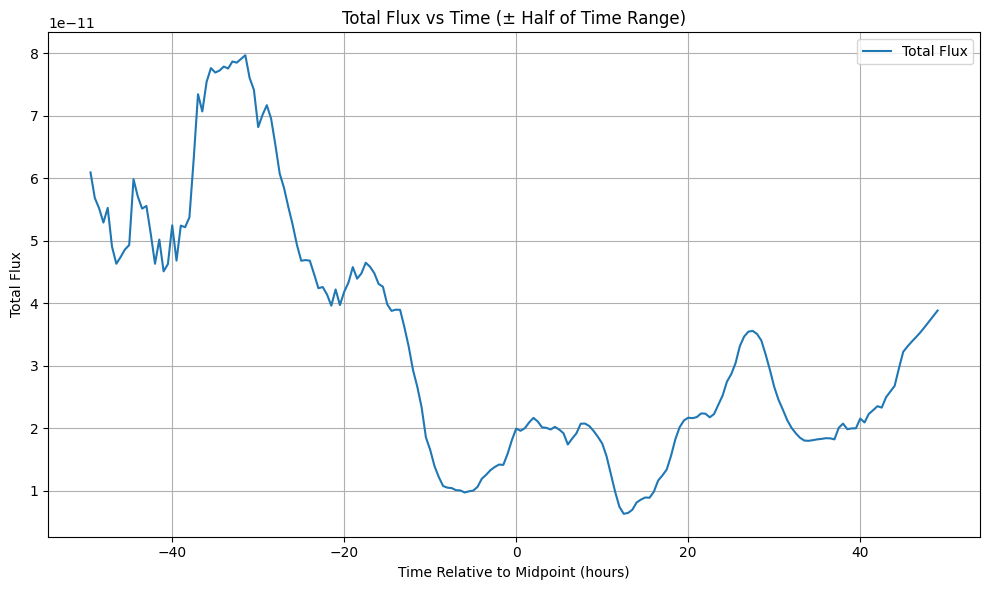

In [6]:
import matplotlib.pyplot as plt
import xarray as xr

# Assuming total_flux_da is your DataArray
# Extract time and values
time = ds['time'].values
flux = ds['total_flux_da'].sel(lev = 41).values

time_midpoint = time[len(time) // 2]  # Middle time point
time_shifted = (time - time_midpoint) / np.timedelta64(1, 'h')  # Convert to hours (or adjust unit as needed)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(time_shifted, flux, label='Total Flux')
plt.xlabel('Time Relative to Midpoint (hours)')
plt.ylabel('Total Flux')
plt.title('Total Flux vs Time (± Half of Time Range)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

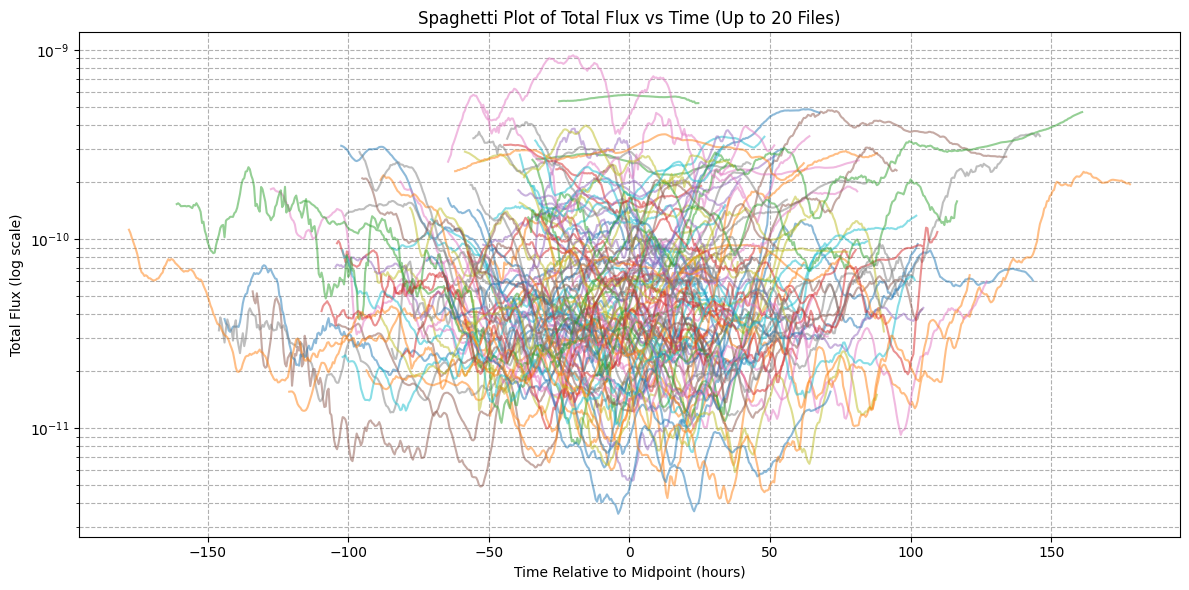

In [7]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import os

# Directory containing .nc files (update with your path)
directory = "."  # Adjust path as needed

# Get list of matching .nc files
matching_files = [f for f in os.listdir(directory) if f.startswith('seri_so4_concentration_') and f.endswith('.nc')]

# Limit to first 20 files
matching_files = matching_files[:100]

# Initialize the plot
plt.figure(figsize=(12, 6))

# Loop through up to 20 matching files
for filename in matching_files:
    # Use a context manager to open the dataset
    file_path = os.path.join(directory, filename)
    with xr.open_dataset(file_path) as ds:
        # Extract total_flux_da DataArray
        total_flux_da = ds['total_flux_da']
        
        # Extract time and values
        time = total_flux_da['time'].values
        flux = total_flux_da.sel(lev = 40).values
        
        # Shift time to center around midpoint
        time_midpoint = time[len(time) // 2]  # Middle time point
        time_shifted = (time - time_midpoint) / np.timedelta64(1, 'h')  # Convert to hours
        
        # Plot the data
        plt.plot(time_shifted, flux, alpha=0.5, label=filename)

# Set logarithmic y-axis
plt.yscale('log')

# Add plot details
plt.xlabel('Time Relative to Midpoint (hours)')
plt.ylabel('Total Flux (log scale)')
plt.title('Spaghetti Plot of Total Flux vs Time (Up to 20 Files)')
plt.grid(True, which="both", ls="--")  # Grid for both major and minor ticks

# Add legend (since 20 files is reasonable for a legend)
#plt.legend()

plt.tight_layout()

# Save the plot (optional, remove if not needed)
plt.savefig('spaghetti_plot_log_20files.png')

# Show the plot
plt.show()

# Composite at max intensity

In [8]:
import os
import xarray as xr

# Directory containing the NetCDF files
directory = '.'  # Change this to your directory path

# List to store datasets
datasets = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('seri_so4_concentration_') and filename.endswith('.nc'):
        # Use a context manager to open the dataset
        file_path = os.path.join(directory, filename)
        with xr.open_dataset(file_path) as data:

            '''
            average_data = data.mean(dim="time", skipna=True) 
            '''
            average_data = data.mean(dim="time", skipna=True) 
            datasets.append(average_data)
            



# Concatenate all datasets along the time dimension
combined_dataset = xr.concat(datasets, dim='time', join='outer')
    
# Ensure times with no data are filled with NaN
combined_dataset = combined_dataset.groupby('time').sum(skipna=True)



    
print(combined_dataset)


<xarray.Dataset> Size: 41kB
Dimensions:        (time: 139, lev: 72)
Coordinates:
  * lev            (lev) float64 576B 1.0 2.0 3.0 4.0 ... 69.0 70.0 71.0 72.0
Dimensions without coordinates: time
Data variables:
    total_flux_da  (time, lev) float32 40kB 5.382e-28 2.857e-27 ... 7.062e-10


# Composite time average

In [9]:
import os
import xarray as xr

# Directory containing the NetCDF files
directory = '.'  # Change this to your directory path

# List to store datasets
datasets = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.startswith('seri_so4_concentration_') and filename.endswith('.nc'):
        # Use a context manager to open the dataset
        file_path = os.path.join(directory, filename)
        with xr.open_dataset(file_path) as data:
            
            average_data = data.mean(dim="time", skipna=True) 
            
            datasets.append(average_data)
            



# Concatenate all datasets along the time dimension
combined_dataset = xr.concat(datasets, dim='time', join='outer')
    
# Ensure times with no data are filled with NaN
combined_dataset = combined_dataset.groupby('time').sum(skipna=True)



    
print(combined_dataset)


<xarray.Dataset> Size: 41kB
Dimensions:        (time: 139, lev: 72)
Coordinates:
  * lev            (lev) float64 576B 1.0 2.0 3.0 4.0 ... 69.0 70.0 71.0 72.0
Dimensions without coordinates: time
Data variables:
    total_flux_da  (time, lev) float32 40kB 5.382e-28 2.857e-27 ... 7.062e-10


In [10]:
combined_dataset

<xarray.Dataset> Size: 41kB
Dimensions:        (time: 139, lev: 72)
Coordinates:
  * lev            (lev) float64 576B 1.0 2.0 3.0 4.0 ... 69.0 70.0 71.0 72.0
Dimensions without coordinates: time
Data variables:
    total_flux_da  (time, lev) float32 40kB 5.382e-28 2.857e-27 ... 7.062e-10

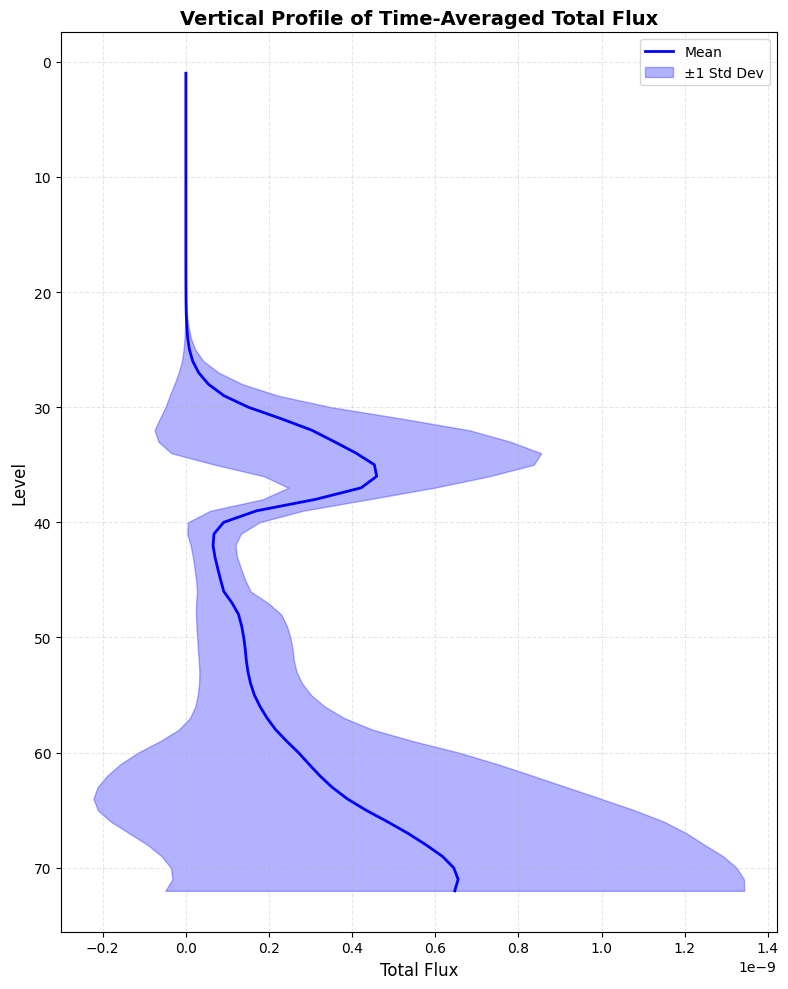

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate time-averaged mean and standard deviation
mean_profile = combined_dataset['total_flux_da'].mean(dim='time')
std_profile = combined_dataset['total_flux_da'].std(dim='time')

# Get the level coordinates
levels = ds['lev'].values

# Create the profile plot
fig, ax = plt.subplots(figsize=(8, 10))

# Plot the mean profile
ax.plot(mean_profile, levels, 'b-', linewidth=2, label='Mean')

# Add shaded region for standard deviation
ax.fill_betweenx(levels, 
                  mean_profile - std_profile, 
                  mean_profile + std_profile,
                  alpha=0.3, 
                  color='blue',
                  label='±1 Std Dev')

# Formatting
ax.set_xlabel('Total Flux', fontsize=12)
ax.set_ylabel('Level', fontsize=12)
ax.set_title('Vertical Profile of Time-Averaged Total Flux', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best')

# Invert y-axis if levels represent altitude/pressure (higher levels at top)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [12]:
combined_dataset['total_flux_da'].isel(time=slice(0,90))

<xarray.DataArray 'total_flux_da' (time: 90, lev: 72)> Size: 26kB
array([[5.3822529e-28, 2.8567250e-27, 1.2850215e-26, ..., 4.5198759e-10,
        4.5611090e-10, 4.2665352e-10],
       [2.7025415e-27, 1.1829015e-26, 4.6011184e-26, ..., 1.4177214e-09,
        1.4271648e-09, 1.3731883e-09],
       [5.0543886e-27, 3.6528774e-26, 1.2445780e-25, ..., 4.6915372e-10,
        4.6923687e-10, 4.6431614e-10],
       ...,
       [9.6958037e-26, 5.0114465e-25, 1.7841137e-24, ..., 9.0144558e-11,
        8.9449392e-11, 8.6246940e-11],
       [1.2986809e-25, 5.9061720e-25, 2.0614148e-24, ..., 2.3739744e-10,
        2.3800886e-10, 2.2522539e-10],
       [1.4352729e-25, 7.2220403e-25, 2.7299810e-24, ..., 8.1604679e-10,
        8.4025542e-10, 8.2215801e-10]], shape=(90, 72), dtype=float32)
Coordinates:
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
Dimensions without coordinates: time

In [13]:
total_flux = combined_dataset['total_flux_da']

In [14]:
total_flux

<xarray.DataArray 'total_flux_da' (time: 139, lev: 72)> Size: 40kB
array([[5.3822529e-28, 2.8567250e-27, 1.2850215e-26, ..., 4.5198759e-10,
        4.5611090e-10, 4.2665352e-10],
       [2.7025415e-27, 1.1829015e-26, 4.6011184e-26, ..., 1.4177214e-09,
        1.4271648e-09, 1.3731883e-09],
       [5.0543886e-27, 3.6528774e-26, 1.2445780e-25, ..., 4.6915372e-10,
        4.6923687e-10, 4.6431614e-10],
       ...,
       [8.5490700e-21, 4.4398525e-20, 1.1933178e-19, ..., 7.0269773e-10,
        7.1754075e-10, 6.5101263e-10],
       [7.2156548e-21, 4.7572046e-20, 1.2973189e-19, ..., 2.2342639e-10,
        2.2078615e-10, 2.1393935e-10],
       [7.6930115e-21, 5.4109364e-20, 1.4787164e-19, ..., 6.0804933e-10,
        6.9833134e-10, 7.0617284e-10]], shape=(139, 72), dtype=float32)
Coordinates:
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
Dimensions without coordinates: time

In [15]:
plsel_da = dspl['pl'].isel(time=1300).sel(lat=25, lon=-90)
rhosel_da = dsrho['airdens'].isel(time=1300).sel(lat=25, lon=-90)

In [16]:
mean_flux = rhosel_da * 1e+6 * 1e+3 * total_flux.mean(dim="time", skipna=True)
std_flux = rhosel_da * 1e+6 * 1e+3 * total_flux.std(dim="time", skipna=True)

In [17]:
std_flux

<xarray.DataArray (lev: 72)> Size: 288B
array([4.43239437e-17, 4.12599728e-16, 1.64881475e-15, 5.53411221e-15,
       1.75115913e-14, 5.45196687e-14, 1.62804069e-13, 4.75192314e-13,
       1.39190450e-12, 4.62037136e-12, 1.68468694e-11, 7.49641946e-11,
       3.15308696e-10, 1.32307354e-09, 5.98249583e-09, 2.47881928e-08,
       8.98147476e-08, 2.99480661e-07, 8.57479847e-07, 2.09944028e-06,
       5.04888567e-06, 1.40576003e-05, 3.99598430e-05, 9.51431211e-05,
       2.13983018e-04, 4.85569733e-04, 1.09842629e-03, 2.27176468e-03,
       4.42166207e-03, 8.18713475e-03, 1.45332655e-02, 2.27088127e-02,
       3.04313619e-02, 3.86356823e-02, 3.99355069e-02, 3.39834839e-02,
       2.58374028e-02, 2.21079364e-02, 2.25664359e-02, 2.01701261e-02,
       1.73646435e-02, 1.65162589e-02, 1.84408035e-02, 2.19554082e-02,
       2.63293236e-02, 3.18228267e-02, 4.63700444e-02, 5.93836941e-02,
       6.73900917e-02, 7.41460323e-02, 7.99718872e-02, 8.49031806e-02,
       9.15165171e-02, 1.01932153e-01, 1.16635054e-01, 1.37198612e-01,
       1.68517411e-01, 2.17299685e-01, 2.91616946e-01, 3.79620224e-01,
       4.53565657e-01, 5.19505918e-01, 5.81727207e-01, 6.37645721e-01,
       6.84899509e-01, 7.15224326e-01, 7.33712554e-01, 7.42536128e-01,
       7.57223606e-01, 7.71556497e-01, 7.88378894e-01, 8.06461930e-01],
      dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2005-06-11T23:29:59.999997
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
    lat      float64 8B 25.0
    lon      float64 8B -90.0

In [18]:
# Convert DataArrays to Datasets with explicit variable names
ds_list = []

# Handle plsel_da
if isinstance(plsel_da, xr.DataArray):
    ds_list.append(plsel_da.to_dataset(name='plsel_data'))
else:
    ds_list.append(plsel_da)

# Handle mean_flux
if isinstance(mean_flux, xr.DataArray):
    ds_list.append(mean_flux.to_dataset(name='mean_flux'))
else:
    ds_list.append(mean_flux)

# Handle std_flux
if isinstance(std_flux, xr.DataArray):
    ds_list.append(std_flux.to_dataset(name='std_flux'))
else:
    ds_list.append(std_flux)

merged_ds = xr.merge(ds_list, compat='no_conflicts')

In [19]:
merged_ds

<xarray.Dataset> Size: 1kB
Dimensions:     (lev: 72)
Coordinates:
    time        datetime64[ns] 8B 2005-06-11T23:29:59.999997
  * lev         (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
    lat         float64 8B 25.0
    lon         float64 8B -90.0
Data variables:
    plsel_data  (lev) float32 288B ...
    mean_flux   (lev) float32 288B 1.486e-17 1.279e-16 ... 0.7511 0.7492
    std_flux    (lev) float32 288B 4.432e-17 4.126e-16 ... 0.7884 0.8065

In [20]:
from metpy.interpolate import log_interpolate_1d
import numpy as np
import xarray as xr

# Define new pressure levels (Pa)
new_levels = np.linspace(
    merged_ds['plsel_data'].values.max(),
    merged_ds['plsel_data'].values.min(),
    num=72
)

# Create a new dataset to store interpolated data
new_ds = xr.Dataset()

# Get all data variables except 'pl' (since pl is a coordinate)
vars_to_interpolate = [var for var in merged_ds.data_vars if var != 'plsel_data']

# Interpolate each variable
for var in vars_to_interpolate:
    # Extract the pressure profile and variable profile
    press_profile = merged_ds['plsel_data'].values
    var_profile = merged_ds[var].values
    
    # Check for NaN or infinite values
    valid_mask = np.isfinite(press_profile) & np.isfinite(var_profile)
    press_profile_clean = press_profile[valid_mask]
    var_profile_clean = var_profile[valid_mask]
    
    # Check if we have enough valid data points
    if len(press_profile_clean) > 1:
        # Ensure pressure profile is monotonically decreasing
        if not np.all(np.diff(press_profile_clean) < 0):
            press_profile_clean = press_profile_clean[::-1]
            var_profile_clean = var_profile_clean[::-1]
        
        # Perform log-pressure interpolation
        try:
            interp_data = log_interpolate_1d(
                new_levels, press_profile_clean, var_profile_clean, fill_value=np.nan
            )
        except Exception as e:
            print(f"Error interpolating {var}: {e}")
            interp_data = np.full_like(new_levels, np.nan)
    else:
        print(f"Not enough valid data points for {var}")
        interp_data = np.full_like(new_levels, np.nan)
    
    # Add interpolated data to the new dataset
    new_ds[var] = xr.DataArray(
        interp_data,
        coords={'press': new_levels},
        dims=['press']
    )

# Also add the new pressure levels as a coordinate
new_ds = new_ds.assign_coords(press=new_levels)

# Save the new dataset
bufferrr = 2.5
name = 'so4_interpolated_concentration_allofall_box{buffer}_futures_pl.nc'.format(buffer=2*bufferrr)
new_ds.to_netcdf(name)

print(f"Saved interpolated dataset to {name}")
print(f"Interpolated variables: {list(new_ds.data_vars)}")

Saved interpolated dataset to so4_interpolated_concentration_allofall_box5.0_futures_pl.nc
Interpolated variables: ['mean_flux', 'std_flux']


In [21]:
new_ds

<xarray.Dataset> Size: 864B
Dimensions:    (press: 72)
Coordinates:
  * press      (press) float32 288B 1.002e+05 9.877e+04 ... 1.413e+03 1.5
Data variables:
    mean_flux  (press) float32 288B 0.7492 0.7509 0.7333 ... 0.000569 1.486e-17
    std_flux   (press) float32 288B 0.8065 0.7897 0.7737 ... 0.0008926 4.432e-17

In [22]:
import pandas as pd

# Count metadata lines manually or inspect first
metadata_lines = 0 #542# Example: modify based on your file

name = "merged_sulfate_data_unfiltered.csv"

df = pd.read_csv(
    name,
    sep=",",           # most ICT files are comma-separated
    skiprows=metadata_lines,
    comment=";",       # ignore comment lines if present
    na_values=["-9999", "-999"]  # missing value codes used in ICARTT
)

print(df.head())


                    Time_UTC  Sulfate_Concentration_60s_avg  \
0  1970-01-01 15:35:30+00:00                       2.681229   
1  1970-01-01 15:36:30+00:00                       2.409264   
2  1970-01-01 15:37:30+00:00                       1.352168   
3  1970-01-01 15:38:30+00:00                       0.113692   
4  1970-01-01 15:39:30+00:00                       0.067067   

   Precision_Error_60s  Detection_Limit_60s  Standard_Error_60s  \
0             0.013651             0.125904            0.036137   
1             0.014900             0.171687            0.043964   
2             0.012488             0.167383            0.100265   
3             0.004139             0.071770            0.006062   
4             0.003432             0.061716            0.005253   

   Total_Uncertainty_60s    UTC   JDAY     INDEX   FLIGHT  ...  \
0               0.038630  56130    256  170001.0     17.0  ...   
1               0.046420  56190    256  170002.0     17.0  ...   
2               0.10

In [23]:
print(df.columns)

Index(['Time_UTC', 'Sulfate_Concentration_60s_avg', 'Precision_Error_60s',
       'Detection_Limit_60s', 'Standard_Error_60s', 'Total_Uncertainty_60s',
       ' UTC', ' JDAY', ' INDEX', ' FLIGHT',
       ...
       ' Rad-1270nm_4STAR-Zenith', ' Rad-1500nm_4STAR-Zenith',
       ' Rad-1565nm_4STAR-Zenith', ' Rad-1580nm_4STAR-Zenith',
       ' Rad-1595nm_4STAR-Zenith', ' Rad-1610nm_4STAR-Zenith',
       ' Rad-1620nm_4STAR-Zenith', ' Rad-1634nm_4STAR-Zenith', 'UTC_dt',
       'time_diff_seconds'],
      dtype='object', length=506)


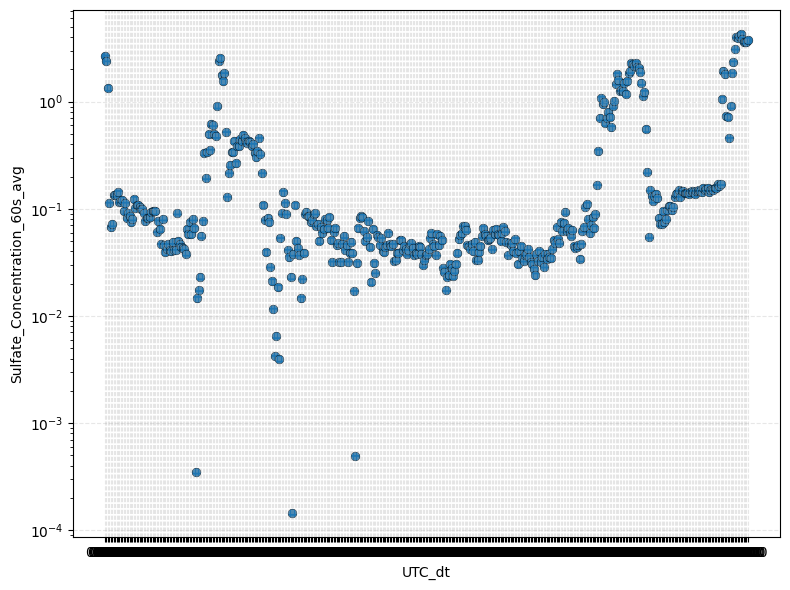

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timezone
import matplotlib.dates as mdates

# Choose your actual columns




#df["UTC_dt"] = df[" UTC"].apply(lambda t: datetime.fromtimestamp(t, tz=timezone.utc))

x = df["UTC_dt"]
y = df["Sulfate_Concentration_60s_avg"]

fig, ax = plt.subplots(figsize=(8, 6))


# 1. Scatter points with nice styling
sns.scatterplot(x=x, y=y, s=40, edgecolor="black", linewidth=0.3)


# 3. Improve axes + formatting

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

#plt.ylim(-0.1,10)
plt.yscale('log')

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


# Filter up

Loaded data from: time_extremes.npz
Number of data points (Filtered): 448
Time range: 1970-01-01 15:35:30+00:00 to 1970-01-01 23:36:30+00:00

Columns in dataset:
['Time_UTC', 'Sulfate_Concentration_60s_avg', 'Precision_Error_60s', 'Detection_Limit_60s', 'Standard_Error_60s', 'Total_Uncertainty_60s', ' UTC', ' JDAY', ' INDEX', ' FLIGHT', ' LOCAL_SUN_TIME', ' LATITUDE', ' LONGITUDE', ' ALTP', ' PRESSURE', ' TEMPERATURE', ' THETA', ' O3COLUMN', ' SZA', ' WNS', ' WND', ' GPS_ALT', ' RadarAlt', ' GRD_SPD', ' TAS', ' IAS', ' MachNumber', ' VerticalSpeed', ' HDG', ' TRK', ' DriftAngle', ' PITCH', ' ROLL', ' StaticTemp_Experimenter', ' PotentialTemp', ' Dewpoint', ' TotalTemp', ' TotalTemp_Experimenter', ' IR_SurfTemp', ' CabinPressure', ' SolarZenithAngle', ' AircraftSunElevation', ' SunAzimuth', ' AircraftSunAzimuth', ' H2O_MixingRatio', ' H2O_VaporPres', ' H2O_SatVaporPresWater', ' H2O_SatVaporPresIce', ' H2O_RelativeHumidity', ' StaticPressure_MMS', ' StaticTemp_MMS', ' TAS_MMS', ' U_MMS',

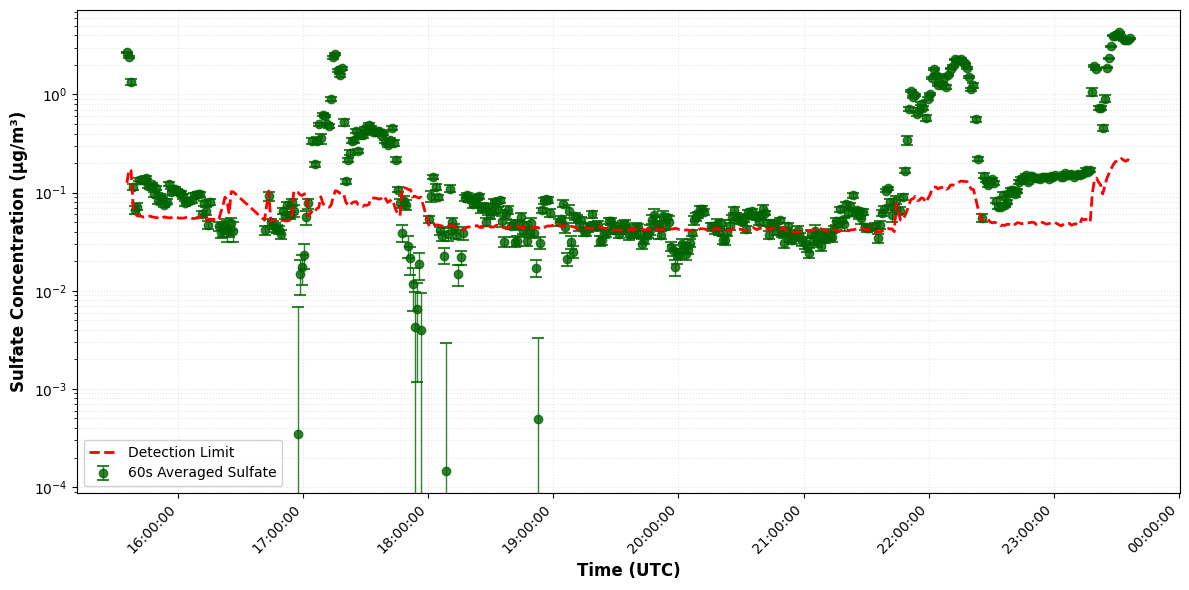

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Load the 60-second averaged data
#filename = 'merged_sulfate_data.csv'
#df = pd.read_csv(filename)

# Convert time column to datetime
df['Time_UTC'] = pd.to_datetime(df['Time_UTC'])

# ---------------------------------------------------------
# FILTERING STEP: Remove values less than the detection limit
# ---------------------------------------------------------
#df = df[df['Sulfate_Concentration_60s_avg'] >= df['Detection_Limit_60s']]

# Display basic information
print("=" * 60)
print(f"Loaded data from: {filename}")
print(f"Number of data points (Filtered): {len(df)}")
if not df.empty:
    print(f"Time range: {df['Time_UTC'].min()} to {df['Time_UTC'].max()}")
    print("\nColumns in dataset:")
    print(df.columns.tolist())
    print("\nFirst few rows:")
    print(df.head())
else:
    print("No data points remain after filtering.")
print("=" * 60)

if not df.empty:
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot sulfate concentration with error bars
    ax.errorbar(df['Time_UTC'], 
                df['Sulfate_Concentration_60s_avg'], 
                yerr=df['Total_Uncertainty_60s'],
                fmt='o', markersize=6, alpha=0.8, 
                capsize=4, capthick=1.5, elinewidth=1,
                label='60s Averaged Sulfate', color='darkgreen',
                zorder=2)

    # Plot detection limit
    ax.plot(df['Time_UTC'], 
            df['Detection_Limit_60s'],
            color='red', linestyle='--', linewidth=2, 
            label='Detection Limit', 
            alpha=1,
            zorder=3)

    # Formatting
    ax.set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sulfate Concentration (μg/m³)', fontsize=12, fontweight='bold')
    #ax.set_title('60-Second Averaged Sulfate Aerosol (<1 μm)', 
    #             fontsize=14, fontweight='bold', pad=15)
    ax.set_yscale('log')
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle=':', which='both')

    # Format x-axis
    ax.xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()

    plt.savefig('SEC4RS_AMS.png')

    # Display statistics
    print("\n" + "=" * 60)
    print("STATISTICS - 60-SECOND AVERAGED DATA (FILTERED)")
    print("=" * 60)
    print(f"Sulfate Concentration:")
    print(f"  Mean: {df['Sulfate_Concentration_60s_avg'].mean():.4f} μg/m³")
    print(f"  Std Dev: {df['Sulfate_Concentration_60s_avg'].std():.4f} μg/m³")
    print(f"  Min: {df['Sulfate_Concentration_60s_avg'].min():.4f} μg/m³")
    print(f"  Max: {df['Sulfate_Concentration_60s_avg'].max():.4f} μg/m³")
    print(f"  Median: {df['Sulfate_Concentration_60s_avg'].median():.4f} μg/m³")

    print(f"\nTotal Uncertainty:")
    print(f"  Mean: {df['Total_Uncertainty_60s'].mean():.4f} μg/m³")
    print(f"  Min: {df['Total_Uncertainty_60s'].min():.4f} μg/m³")
    print(f"  Max: {df['Total_Uncertainty_60s'].max():.4f} μg/m³")

    print(f"\nDetection Limit:")
    print(f"  Mean: {df['Detection_Limit_60s'].mean():.4f} μg/m³")
    print(f"  Min: {df['Detection_Limit_60s'].min():.4f} μg/m³")
    print(f"  Max: {df['Detection_Limit_60s'].max():.4f} μg/m³")

    print(f"\nPrecision Error:")
    print(f"  Mean: {df['Precision_Error_60s'].mean():.4f} μg/m³")

    print(f"\nStandard Error:")
    print(f"  Mean: {df['Standard_Error_60s'].mean():.4f} μg/m³")
    print("=" * 60)

    plt.show()

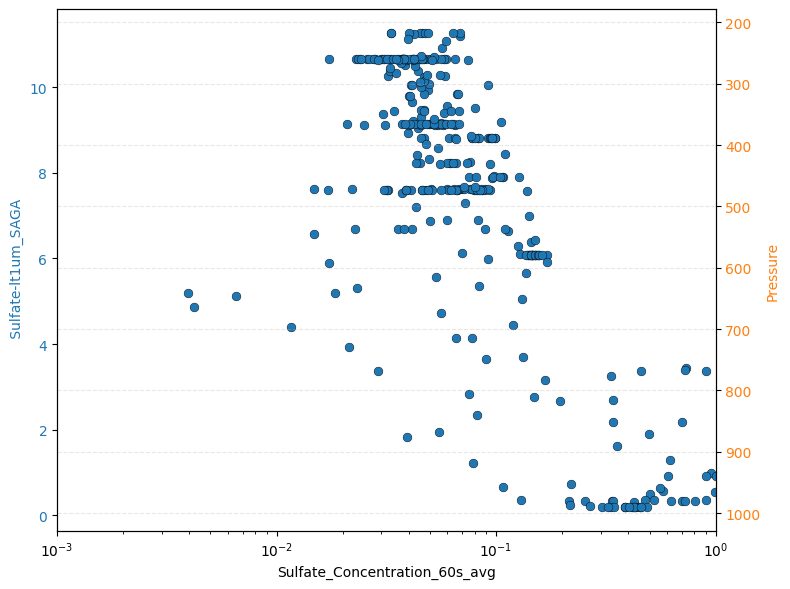

In [29]:
from datetime import datetime, timezone, time

df["UTC_dt"] = df[" UTC"].apply(lambda t: datetime.fromtimestamp(t, tz=timezone.utc))

# Define time period (e.g., between 3:30 PM and 11:00 PM)
start_time = time(16, 00) 
end_time = time(23, 30)    

# Define altitude range
alt_min = 0
alt_max = 11.5

# Filter by both altitude and time of day
df_filtered = df[
    (df[" ALTP"] >= alt_min) & 
    (df[" ALTP"] <= alt_max) &
    (df["UTC_dt"].dt.time >= start_time) &
    (df["UTC_dt"].dt.time <= end_time)
]

# plotting
r = np.sqrt((df_filtered[" LONGITUDE"].values - 266)**2 + (df_filtered[" LATITUDE"].values - 16)**2)
x = df_filtered["Sulfate_Concentration_60s_avg"] #df_filtered["UTC_dt"]  # Fixed: use df_filtered instead of df
y = df_filtered[" ALTP"]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot sulfate on left y-axis
sns.scatterplot(x=x, y=y, s=40, edgecolor="black", linewidth=0.3, ax=ax)
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_ylabel(' Sulfate-lt1um_SAGA', color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_xlim(1e-3,1)

# Create second y-axis for altitude
ax2 = ax.twinx()
ax2.plot(x,  df_filtered[" PRESSURE"], color='C1', alpha=0.0, linewidth=1.5)
ax2.invert_yaxis() 
ax2.set_ylabel('Pressure', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

(1000.0, 10.0)

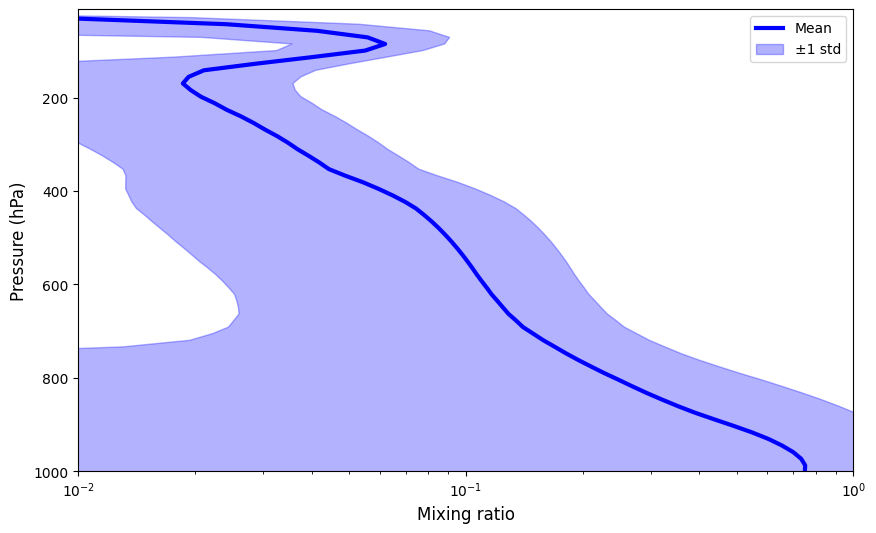

In [30]:
# Get mean and std data
mean_data = new_ds['mean_flux']
std_data = new_ds['std_flux']
lev = new_ds['press']

# Define level range
level_range = (lev >= 1000) & (lev <= 110000)
selected_mean = mean_data[level_range]
selected_std = std_data[level_range]
selected_lev = lev[level_range] / 100

# Calculate upper and lower bounds
upper_bound = selected_mean + selected_std
lower_bound = selected_mean - selected_std

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the mean line
plt.plot(selected_mean, selected_lev, linewidth=3, label='Mean', color='blue')

# Add shaded region for ±1 standard deviation
plt.fill_betweenx(selected_lev, lower_bound, upper_bound, 
                   alpha=0.3, color='blue', label='±1 std')

# Optionally, add lines for the bounds
# plt.plot(upper_bound, selected_lev, '--', linewidth=1, color='blue', alpha=0.5)
# plt.plot(lower_bound, selected_lev, '--', linewidth=1, color='blue', alpha=0.5)

plt.xlim(1e-2,1)
plt.ylabel('Pressure (hPa)', fontsize=12)
plt.xlabel('Mixing ratio', fontsize=12)
plt.xscale('log')
plt.legend(loc='best')
plt.gca().invert_yaxis()  # Invert the y-axis
plt.ylim(1000, 10)  # Set y-axis limit from 1000 to 30 hP

# AMS

# R from TC

In [31]:
def distance_km(lat1, lon1, lat2, lon2):
    R = 6371 # Earth radius in km
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)

    a = np.sin(dLat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dLon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c # Returns Kilometers


center_lat = 19.2
center_lon = 360 - 95.3

# Calculate r in km using the Haversine function
# Pass the center coordinates and the observation coordinates
rnew = distance_km(center_lat, center_lon, df[" LATITUDE"], df[" LONGITUDE"])

In [32]:
rnew

0      1159.537833
1      1161.460235
2      1156.223351
3      1149.054635
4      1141.799050
          ...     
443    1147.618454
444    1145.125842
445    1142.847074
446    1141.931500
447    1142.681960
Length: 448, dtype: float64

In [42]:
df['rnew'] = rnew

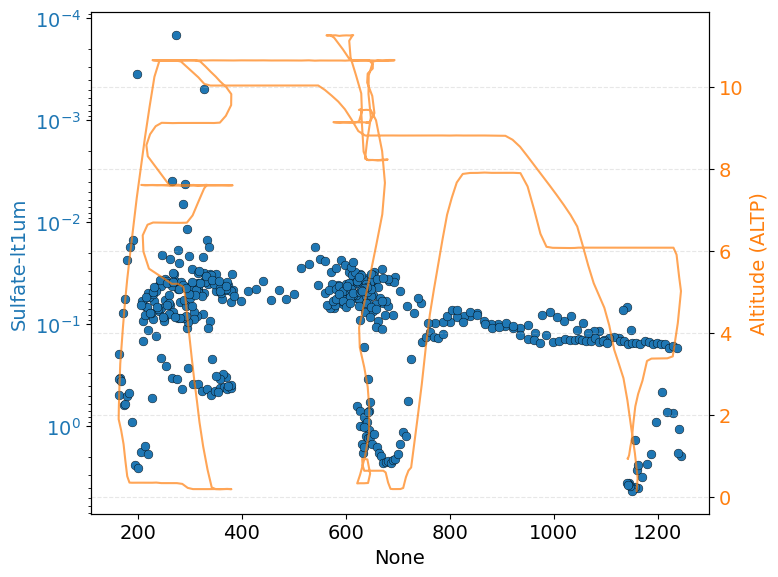

In [43]:
from datetime import datetime, timezone, time

df["UTC_dt"] = df[" UTC"].apply(lambda t: datetime.fromtimestamp(t, tz=timezone.utc))

# Define time period (e.g., between 3:30 PM and 11:00 PM)
start_time = time(15, 00) 
end_time = time(23, 55)    

# Define altitude range
alt_min = 0
alt_max = 12.5

# Filter by both altitude and time of day
df_filtered = df[
    (df[" ALTP"] >= alt_min) & 
    (df[" ALTP"] <= alt_max) &
    (df["UTC_dt"].dt.time >= start_time) &
    (df["UTC_dt"].dt.time <= end_time)
]

# plotting
r = np.sqrt((df_filtered[" LONGITUDE"].values - 266)**2 + (df_filtered[" LATITUDE"].values - 16)**2)
x = rnew # df_filtered["UTC_dt"]  # Fixed: use df_filtered instead of df
y = df_filtered["Sulfate_Concentration_60s_avg"]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot sulfate on left y-axis
sns.scatterplot(x=x, y=y, s=40, edgecolor="black", linewidth=0.3, ax=ax)
ax.set_yscale('log')
ax.set_ylabel('Sulfate-lt1um', color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.invert_yaxis()

# Create second y-axis for altitude
ax2 = ax.twinx()
ax2.plot(x,  df_filtered[" ALTP"], color='C1', alpha=0.7, linewidth=1.5)
#ax2.invert_yaxis() 
ax2.set_ylabel('Altitude (ALTP)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
#df["r_km"]

In [45]:
import matplotlib as mpl

In [46]:
#reds = mpl.cm.Reds

/tmp/ipykernel_1423121/3852270676.py:54: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  sc_below = ax.scatter(df_below["Sulfate_Concentration_60s_avg"],
/tmp/ipykernel_1423121/3852270676.py:54: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc_below = ax.scatter(df_below["Sulfate_Concentration_60s_avg"],


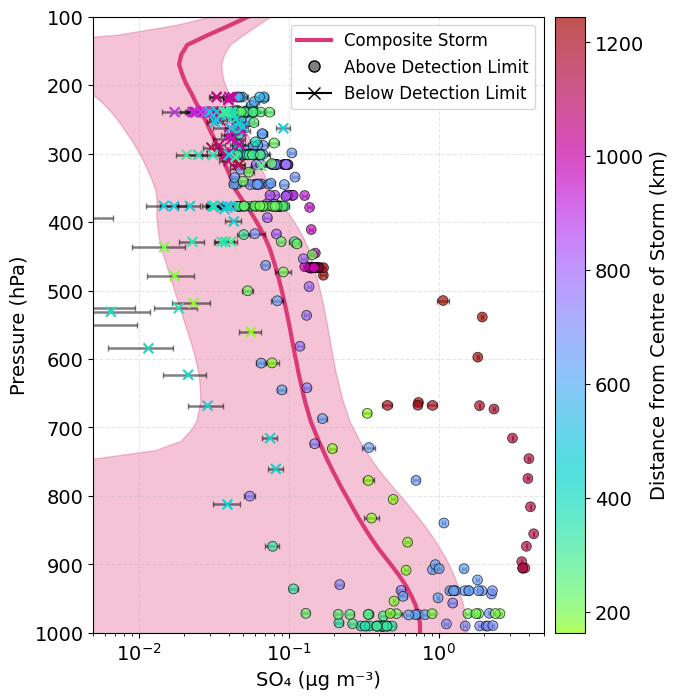

In [90]:
import matplotlib as mpl
import colormaps as cmaps 
mpl.rcParams.update({'font.size': 14})

# 1. Calculate radial distance r
df["r"] = np.sqrt((df[" LONGITUDE"] - 266)**2 + (df[" LATITUDE"] - 16)**2)
start_time = time(16, 00) 
end_time = time(23, 55)  

# 2. Filter for altitude range
df_plot = df[(df[" ALTP"] >= alt_min) & (df[" ALTP"] <= alt_max) & 
             (df["UTC_dt"].dt.time >= start_time) &   
             (df["UTC_dt"].dt.time <= end_time)].copy()
df_plot = df_plot.sort_values(by="rnew", ascending=False)

# 3. Separate data above and below detection limit
df_above = df_plot[df_plot["Sulfate_Concentration_60s_avg"] >= df_plot["Detection_Limit_60s"]]
df_below = df_plot[df_plot["Sulfate_Concentration_60s_avg"] < df_plot["Detection_Limit_60s"]]

# 4. Create figure and axis explicitly
fig, ax = plt.subplots(figsize=(7, 8))

# 5. Plot the mean profile and shaded region
ax.plot(selected_mean, selected_lev, linewidth=3, label='Model Composite Storm', color=cmaps.sunsetdark(0.7))
ax.fill_betweenx(selected_lev, lower_bound, upper_bound, alpha=0.3, color=cmaps.sunsetdark(0.6))

# 6. Scatter ABOVE detection limit (filled circles)
if not df_above.empty:
    sc = ax.scatter(df_above["Sulfate_Concentration_60s_avg"], 
                    df_above[" PRESSURE"], 
                    c=df_above["rnew"], 
                    cmap=cmaps.neon_r,
                    s=50, 
                    edgecolor='black', 
                    linewidth=0.6, 
                    alpha=0.7, 
                    zorder=5,
                    label='Above DL')
    
    # Error bars for above detection limit
    ax.errorbar(df_above["Sulfate_Concentration_60s_avg"], 
                df_above[" PRESSURE"], 
                xerr=df_above["Total_Uncertainty_60s"], 
                fmt='none', 
                ecolor='black', 
                elinewidth=1.8, 
                capsize=2, 
                alpha=0.5, 
                zorder=4)
    

# 7. Scatter BELOW detection limit (open triangles)
if not df_below.empty:
    sc_below = ax.scatter(df_below["Sulfate_Concentration_60s_avg"], 
                          df_below[" PRESSURE"], 
                          c=df_below["rnew"], 
                          cmap=cmaps.neon_r,
                          s=50, 
                          marker='x',  # downward triangle
                          edgecolor='black', 
                          linewidth=1.5,
                          facecolors='none',  # open/hollow markers
                          alpha=1, 
                          zorder=5,
                          label='Below DL')
    
    # Error bars for below detection limit
    ax.errorbar(df_below["Sulfate_Concentration_60s_avg"], 
                df_below[" PRESSURE"], 
                xerr=df_below["Total_Uncertainty_60s"], 
                fmt='none', 
                ecolor='black', 
                elinewidth=1.8, 
                capsize=2, 
                alpha=0.5, 
                zorder=4)

# 8. Add colorbar (use 'sc' which should exist if df_above is not empty)
if not df_above.empty:
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label('Distance from Centre of Storm (km)', fontsize=14)
elif not df_below.empty:
    # If only below-limit data exists, use that for colorbar
    cbar = fig.colorbar(sc_below, ax=ax, pad=0.02)
    cbar.set_label('Distance from Centre of Storm (km)', fontsize=14)

# 9. Formatting
ax.set_xscale('log')
ax.set_xlim(5 * 1e-3, 5)
ax.set_ylim(100, 1000)
ax.invert_yaxis()
ax.set_ylabel('Pressure (hPa)', fontsize=14)
ax.set_xlabel('SO₄ (µg m⁻³)', fontsize=14)

# Add legend for detection limit markers
#ax.legend(loc='upper right', fontsize=10)

ax.grid(True, linestyle="--", alpha=0.3)


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=cmaps.sunsetdark(0.7), linewidth=3, label='Composite Storm'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='black', markersize=8, label='Above Detection Limit'),
    Line2D([0], [0], marker='x', color='black', markersize=8,
           linewidth=1.5, label='Below Detection Limit'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)


plt.savefig(name + 'AMS60_r_unfiltered' + '.png', bbox_inches='tight', transparent=True)
plt.show()